# SkinCare AI — Simple CNN Baseline

## Objective

This notebook builds a first baseline model using a simple Convolutional Neural Network (CNN).

The goal is to:
- Load the selected skin disease classes
- Apply basic preprocessing
- Train a simple CNN from scratch
- Evaluate the model on the test set
- Analyze learning curves to detect overfitting or underfitting

This baseline model will later be compared with improved CNN architectures and transfer learning models.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

2026-05-15 12:25:40.469762: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778847940.875214      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778847941.003133      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778847941.984832      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778847941.984874      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778847941.984877      57 computation_placer.cc:177] computation placer alr

In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
DATASET_PATH = "/kaggle/input/datasets/pacificrm/skindiseasedataset/SkinDisease/SkinDisease"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train exists: True
Test exists: True


In [4]:
SELECTED_CLASSES = [
    "Acne",
    "Eczema",
    "Psoriasis",
    "Rosacea"
]

NUM_CLASSES = len(SELECTED_CLASSES)

print("Selected classes:", SELECTED_CLASSES)
print("Number of classes:", NUM_CLASSES)

Selected classes: ['Acne', 'Eczema', 'Psoriasis', 'Rosacea']
Number of classes: 4


## Data Preprocessing

The images are resized to 224 × 224 pixels and normalized by scaling pixel values between 0 and 1.

A validation split is created from the training set to monitor model performance during training.

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
EPOCHS = 15

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode="categorical",
    subset="validation",
    shuffle=True,
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode="categorical",
    shuffle=False
)

Found 2143 images belonging to 4 classes.
Found 534 images belonging to 4 classes.
Found 293 images belonging to 4 classes.


In [7]:
print("Class indices:")
print(train_generator.class_indices)

Class indices:
{'Acne': 0, 'Eczema': 1, 'Psoriasis': 2, 'Rosacea': 3}


## Simple CNN Architecture

The first model is a simple CNN trained from scratch.

It contains:
- Convolutional layers to extract visual features
- MaxPooling layers to reduce spatial dimensions
- Dense layers for classification
- Softmax output layer for multi-class prediction

This model is used as a baseline for comparison with more advanced models.

In [8]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1778847985.187026      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778847985.193337      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [9]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training

The model is trained using categorical crossentropy because this is a multi-class classification problem.

The Adam optimizer is used because it is adaptive and commonly performs well in deep learning tasks.

Early stopping is applied to stop training when validation loss stops improving.

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [11]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1778847990.125687     149 service.cc:152] XLA service 0x7c8e500022c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778847990.125740     149 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778847990.125748     149 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778847990.646344     149 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-15 12:26:33.905291: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 12:26:34.054641: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 2/67 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.3438 - loss: 1.4435 

I0000 00:00:1778847997.317382     149 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 8/67 ━━━━━━━━━━━━━━━━━━━━ 19s 322ms/step - accuracy: 0.3489 - loss: 1.4081

2026-05-15 12:26:41.788547: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 12:26:41.936339: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


67/67 ━━━━━━━━━━━━━━━━━━━━ 47s 564ms/step - accuracy: 0.3716 - loss: 1.3113 - val_accuracy: 0.4288 - val_loss: 1.2024
Epoch 2/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step - accuracy: 0.4901 - loss: 1.1570 - val_accuracy: 0.5094 - val_loss: 1.1740
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 177ms/step - accuracy: 0.5323 - loss: 1.0761 - val_accuracy: 0.5131 - val_loss: 1.1472
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 172ms/step - accuracy: 0.5265 - loss: 1.0433 - val_accuracy: 0.5318 - val_loss: 1.0816
Epoch 5/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 176ms/step - accuracy: 0.5635 - loss: 0.9545 - val_accuracy: 0.5150 - val_loss: 1.1066
Epoch 6/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 178ms/step - accuracy: 0.5969 - loss: 0.9086 - val_accuracy: 0.5131 - val_loss: 1.0603
Epoch 7/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 172ms/step - accuracy: 0.6434 - loss: 0.8341 - val_accuracy: 0.5337 - val_loss: 1.0489
Epoch 8/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 12s 173ms/step - accuracy: 0.6441 - loss: 0.8440 - val_accuracy: 0.539

## Learning Curves

The accuracy and loss curves are plotted to analyze the training behavior.

They help identify:
- Good learning
- Overfitting
- Underfitting

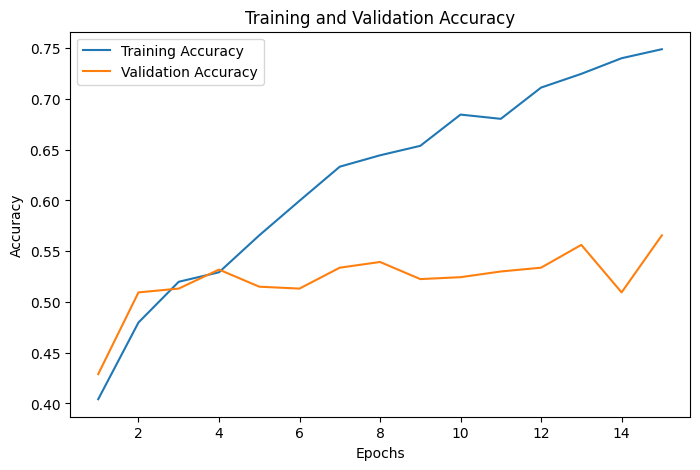

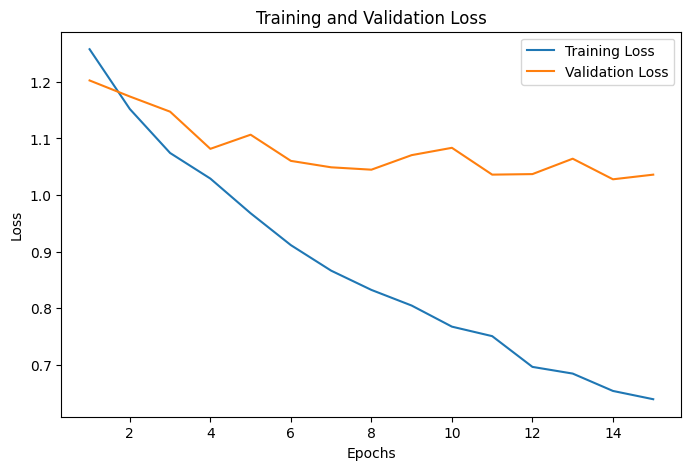

In [12]:
def plot_learning_curves(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_learning_curves(history)

In [13]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 426ms/step - accuracy: 0.4638 - loss: 1.2784
Test Loss: 1.0604184865951538
Test Accuracy: 0.5187713503837585


In [14]:
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

print("Predicted labels:", y_pred[:10])
print("True labels:", y_true[:10])

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step
Predicted labels: [0 1 0 2 2 0 2 2 2 0]
True labels: [0 0 0 0 0 0 0 0 0 0]


In [15]:
class_labels = list(test_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_labels
)

print(report)

              precision    recall  f1-score   support

        Acne       0.70      0.40      0.51        65
      Eczema       0.63      0.46      0.54       112
   Psoriasis       0.40      0.66      0.50        88
     Rosacea       0.55      0.57      0.56        28

    accuracy                           0.52       293
   macro avg       0.57      0.52      0.53       293
weighted avg       0.57      0.52      0.52       293



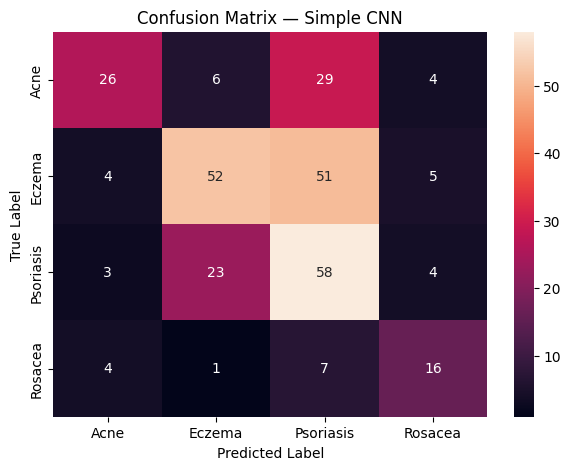

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix — Simple CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [17]:
model.save("/kaggle/working/simple_cnn_baseline.keras")
print("Model saved successfully.")

Model saved successfully.


## Results Interpretation

The simple CNN baseline provides an initial performance reference for the skin disease classification task.

If the training accuracy is much higher than the validation accuracy, this indicates overfitting.  
If both training and validation accuracies are low, this indicates underfitting.

This baseline model will be compared with an improved CNN using data augmentation, dropout and batch normalization in the next notebook.